# EDA: train_final.src.tok
Plain pre-tokenized corpus, one sentence per line, no labels. Zipped in `train_final.zip`. Read as text, not pandas, to keep memory sane.

In [1]:
import re
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

## Line/word counts (streaming, one pass)

In [2]:
n_lines = 0
word_lens = []
char_lens = []
vocab = Counter()
import zipfile, io
with zipfile.ZipFile('../data/train_final.zip') as zf:
    with io.TextIOWrapper(zf.open('train_final.src.tok'), encoding='utf-8') as f:
        for line in f:
            line = line.rstrip('\n')
            toks = line.split()
            n_lines += 1
            word_lens.append(len(toks))
            char_lens.append(len(line))
            vocab.update(toks)
print('lines:', n_lines)
print('unique tokens:', len(vocab))
print('total tokens:', sum(word_lens))

lines: 3803957
unique tokens: 99018
total tokens: 126652466


## Sentence length distribution (words / chars)

In [3]:
word_lens = np.array(word_lens)
char_lens = np.array(char_lens)
import pandas as pd
pd.Series(word_lens).describe()

count    3.803957e+06
mean     3.329493e+01
std      8.775117e+00
min      1.000000e+01
25%      2.800000e+01
50%      3.300000e+01
75%      3.800000e+01
max      1.350000e+02
dtype: float64

In [4]:
pd.Series(char_lens).describe()

count    3.803957e+06
mean     1.827558e+02
std      4.727612e+01
min      3.100000e+01
25%      1.530000e+02
50%      1.830000e+02
75%      2.100000e+02
max      6.280000e+02
dtype: float64

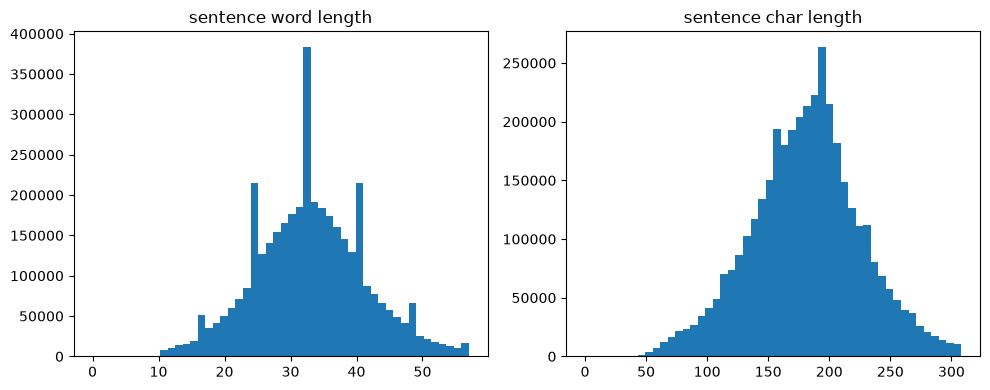

In [5]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(word_lens, bins=50, range=(0, np.percentile(word_lens,99))); ax[0].set_title('sentence word length')
ax[1].hist(char_lens, bins=50, range=(0, np.percentile(char_lens,99))); ax[1].set_title('sentence char length')
plt.tight_layout(); plt.show()

## Token category breakdown: word / number / symbol

In [6]:
def categorize(tok):
    if re.fullmatch(r'[0-9]+', tok):
        return 'number'
    if re.fullmatch(r"[a-z']+", tok, re.IGNORECASE):
        return 'word'
    return 'symbol'

cat_counts = Counter()
for tok, c in vocab.items():
    cat_counts[categorize(tok)] += c
cat_counts

Counter({'word': 110830769, 'symbol': 13199166, 'number': 2622531})

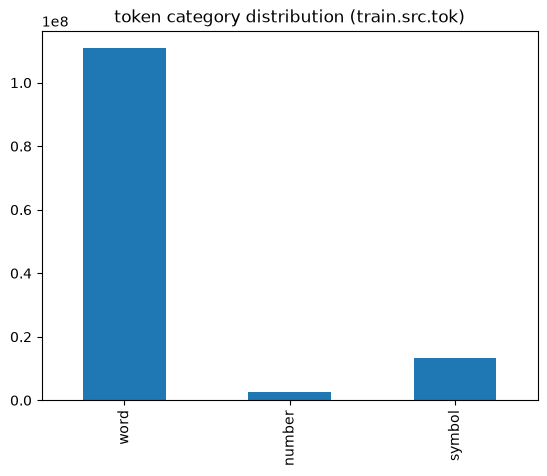

In [7]:
pd.Series(cat_counts).plot.bar(title='token category distribution (train.src.tok)'); plt.show()

## Vocabulary: most / least common tokens

In [8]:
vocab_series = pd.Series(vocab).sort_values(ascending=False)
print('unique tokens:', len(vocab_series))
vocab_series.head(30)

unique tokens: 99018


the          6088593
.            5246235
,            4036278
a            3276156
of           3152587
to           2917657
in           2702830
and          1911496
-            1789854
s            1786979
on           1696100
'            1671709
for          1081026
said         1024734
11           1017456
1             865577
that          753486
with          663134
at            601400
an            575101
as            570875
"             556982
from          525364
by            523564
111           492745
tuesday       470389
wednesday     469377
has           467632
thursday      462148
his           460489
dtype: int64

In [9]:
vocab_series.tail(30)

ranarridh         5
biographic        5
berthes           5
yanshan           5
krist             5
fpd               5
kabbani           5
rongjuan          5
micra             5
pitofsky          5
shoppe            5
yep               5
anno              5
maidstone         5
diskettes         5
misunderstands    5
lusofonia         5
tei               5
bacellar          5
dazhu             5
turksat           5
gelete            5
siradovic         5
shpilevsky        5
issn              4
emilen            2
baptistan         2
gmn               1
tizin             1
ddn               1
dtype: int64

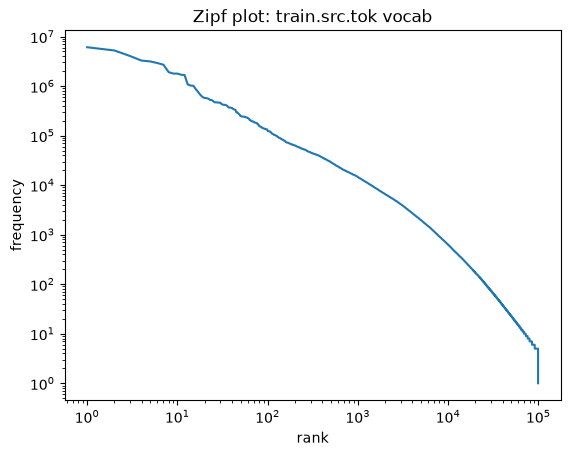

In [10]:
# Zipf check: rank vs frequency, log-log
ranks = np.arange(1, len(vocab_series)+1)
plt.loglog(ranks, vocab_series.values)
plt.xlabel('rank'); plt.ylabel('frequency'); plt.title('Zipf plot: train.src.tok vocab')
plt.show()

## Special tokens ([UNK], punctuation placeholders like -lrb-/-rrb-)

In [11]:
special_pattern = re.compile(r'^\[.*\]$|^-[a-z]+-$', re.IGNORECASE)
specials = {tok: c for tok, c in vocab.items() if special_pattern.match(tok)}
pd.Series(specials).sort_values(ascending=False)

[UNK]    414394
dtype: int64

## Cross-check vocab overlap with dev/test answer & context vocab

In [12]:
import json
try:
    with open('../data/dev_token_list.json') as f:
        dev_words = set(json.load(f))
    with open('../data/test_token_list.json') as f:
        test_words = set(json.load(f))
    train_vocab = set(vocab.keys())
    print('train vocab size:', len(train_vocab))
    print('dev answer tokens in train vocab:', len(dev_words & train_vocab), '/', len(dev_words))
    print('test context tokens in train vocab:', len(test_words & train_vocab), '/', len(test_words), '(% of test vocab covered by train)')
    print('train tokens also in test vocab:', len(train_vocab & test_words), '/', len(train_vocab), '(% of train vocab appearing in test)')
except FileNotFoundError:
    print('run dev_eda.ipynb / test_eda.ipynb first to generate the token-list json files')

train vocab size: 99018
dev answer tokens in train vocab: 10306 / 10308
test context tokens in train vocab: 44447 / 44448 (% of test vocab covered by train)
train tokens also in test vocab: 44447 / 99018 (% of train vocab appearing in test)


In [13]:
missing_dev = sorted(dev_words - train_vocab)
missing_test = sorted(test_words - train_vocab)
print('dev answer words missing from train vocab:', missing_dev)
print('test context words missing from train vocab:', missing_test)

dev answer words missing from train vocab: ['[', ']']
test context words missing from train vocab: ['[']
